In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import sympy as smp

In [2]:
lineClors = ['cornflowerblue',
             'tomato',
            'darkseagreen',
            'sandybrown',
            'teal']
ftSize_ax = 12
ftSize_ti = 16

# Problem 1

Simple population models, like the Logistic Equation $\dot{P}=r\,P\,(1-P/K)$, exhibit approximately-exponential growth at small population sizes ($P\approx 0$). In population biology, an Allee effect is a phenomenon where populations at very low population densities will exhibit slower than exponential growth (\textit{weak Allee effect}) or will decline following a negative growth rate (\textit{strong Allee effect}). A strong Allee effect incorporated into a logistic growth model can be achieved, for example, with $$\dot{P}=r\,(P-\alpha)\,P\,(1-P/K)$$ where $\alpha$ is an unstable equilibrium value. Let  $r=1$, $K=100$, $\alpha=5$.

## (a) 
[10 points] Use `ode()` from the `deSolve` package in R (or if you must, you can use analogous code in your preferred alternative such as python or matlab) and generate a plot of two different numerical solutions starting at $P_0=4$ and $P_0=5$. Include your code in your answer.

-----

In [3]:
t = np.linspace(0,2,50)

def dPdt_f(P,t,r=1,K=100,alph=5):
    return r*(P-alph)*P*(1-P/K)

In [4]:
P0_1 = sp.integrate.odeint(dPdt_f,4,t)
P0_2 = sp.integrate.odeint(dPdt_f,5,t)

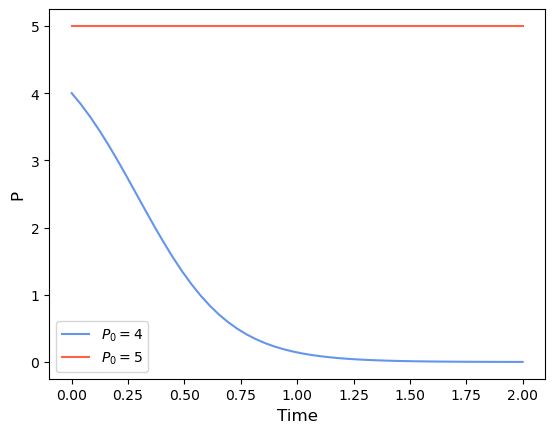

In [5]:
plt.plot(t,P0_1,
        label=r'$P_0=4$',color=lineClors[0])
plt.plot(t,P0_2,
        label=r'$P_0=5$',color=lineClors[1])

plt.ylabel('P',fontsize=ftSize_ax)
plt.xlabel('Time',fontsize=ftSize_ax)
plt.legend()

# plt.savefig('./exam2_plts/p1a_orbs.png', transparent=True, dpi=200, bbox_inches='tight')
plt.show()

## (b)

[10 points] Does this system exhibit bistability? Justify your answer beyond the simulation output from part (a). If your answer is "no", provide a convincing argument that any attractors are globally stable (at least when restricted to values $P\geq 0$). If your answer is "yes", clearly define 

* (i) the **attractors** involved 
* (ii) the associated **separatrix**.

-----

Create symbolic function for $\dot P$

In [6]:
P, r, a, K = smp.symbols('P r a K')

dPdt = r*(P-a)*P*(1-P/K)

dPdt

P*r*(1 - P/K)*(P - a)

Find roots and save them to variables

In [7]:
r0 = smp.solve(dPdt,P)[0]
r1 = smp.solve(dPdt,P)[1]
r2 = smp.solve(dPdt,P)[2]

smp.solve(dPdt,P)

[0, K, a]

Compute $\frac{\partial \dot P}{\partial P}$

In [8]:
J = smp.diff(dPdt,P)
J

P*r*(1 - P/K) + r*(1 - P/K)*(P - a) - P*r*(P - a)/K

Substitute found roots for $P$ and given constants 

In [9]:
J0 = J.subs(P,r0)
J0.subs([[a,5],[r,1],[K,100]])

-5

In [10]:
J1 = J.subs(P,r1)
J1.subs([[a,5],[r,1],[K,100]])

-95

In [11]:
J2 = J.subs(P,r2)
J2.subs([[a,5],[r,1],[K,100]])

19/4

More simulations 

In [12]:
t = np.linspace(0,1,100)

P0_1 = sp.integrate.odeint(dPdt_f,4,t)
P0_2 = sp.integrate.odeint(dPdt_f,5,t)
P0_3 = sp.integrate.odeint(dPdt_f,6,t)
P0_4 = sp.integrate.odeint(dPdt_f,110,t)
P0_5 = sp.integrate.odeint(dPdt_f,-5,t)

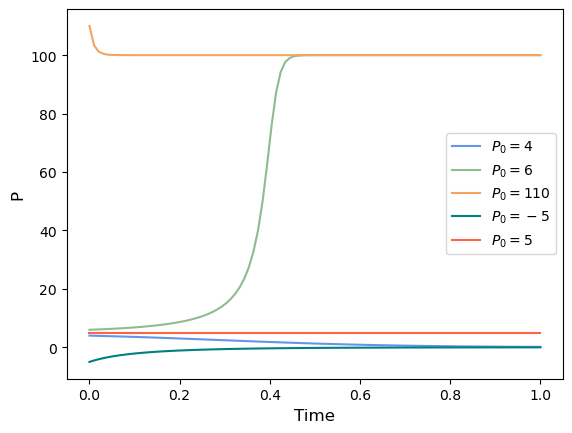

In [13]:
plt.plot(t,P0_1,
        label=r'$P_0=4$',color=lineClors[0])

plt.plot(t,P0_3,
        label=r'$P_0=6$',color=lineClors[2])
plt.plot(t,P0_4,
        label=r'$P_0=110$',color=lineClors[3])
plt.plot(t,P0_5,
        label=r'$P_0=-5$',color=lineClors[4])
plt.plot(t,P0_2,
        label=r'$P_0=5$',color=lineClors[1],linestyle='-')

plt.ylabel('P',fontsize=ftSize_ax)
plt.xlabel('Time',fontsize=ftSize_ax)
plt.legend()

# plt.savefig('./exam2_plts/p1b_orbs.png', transparent=True, dpi=200, bbox_inches='tight')
plt.show()

## (c)

[10 points] What bifurcation occurs as $\alpha$ passes through $0$? Justify your answer, and write a **normal form** for that bifurcation. Explain which equilibria in the original system "match up" with the equilibria of the normal form.

-----

Turn the symbolic functions for `dPdt` and `r0` into numerical functions for plotting.

In [14]:
dPdt_f = smp.lambdify([a,P],dPdt.subs([[K,100],[r,1]]))
r2_f = smp.lambdify(a,r2)

Make grid for plotting

In [15]:
n = 10
pv = np.linspace(-1,1,n)
av = np.linspace(-1,1,n)

aG, pG = np.meshgrid(av,pv)

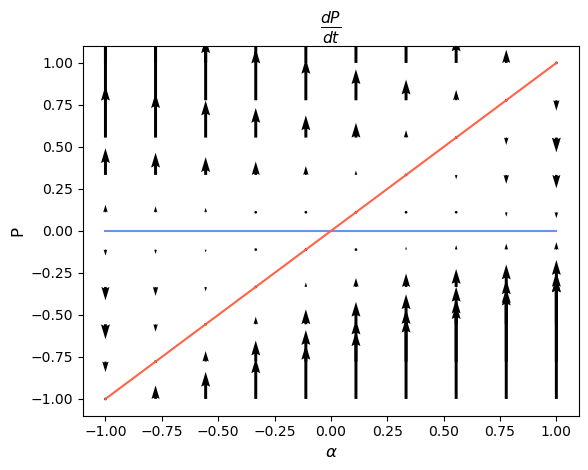

In [16]:
plt.plot(av,np.zeros(av.size),color=lineClors[0]) 
plt.plot(av,r2_f(av),color=lineClors[1])

V = dPdt_f(aG,pG)
U = np.zeros(pG.shape)
plt.quiver(aG,pG,U,V)

plt.ylabel('P',fontsize=ftSize_ax)
plt.xlabel(r'$\alpha$',fontsize=ftSize_ax)

plt.title(r'$\frac{dP}{dt}$',fontsize=ftSize_ti)
# plt.savefig('./exam2_plts/p1c_vecField.png', transparent=True, dpi=200, bbox_inches='tight')
plt.show()

Redefining the function `dPdt_f` to have more arguments, because `scipy` is being dumb (aka Im being dumb)

In [17]:
def dPdt_f(P,t,alph,r,K):
    return r*(P-alph)*P*(1-P/K)

Running several simulations for $IC: P= -0.1$ at a range of $\alpha$

In [18]:
A = np.linspace(-1,1,50)
t = np.arange(0,6,1)

P = np.empty((A.size,t.size))
idx = 0
for a in A:
    
    x = -0.1 #np.random.random()
    P[idx] = sp.integrate.odeint(dPdt_f,x,t,args=(a,1,100))[:,0]
    idx +=1

In [19]:
clors=['dimgrey',
      'slategray',
      'steelblue',
      'cornflowerblue',
      'dodgerblue',
      'deepskyblue']

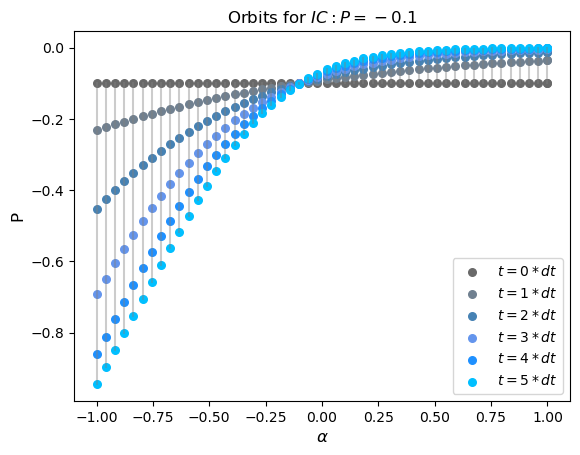

In [20]:
ps = 30

idx = 0
for a in A:
    plt.plot(a*np.ones(P.shape[1]),P[idx],alpha=0.4,color='gray')
    for jdx in range(t.size):
        plt.scatter(a,P[idx,jdx],s=ps,color=clors[jdx])
    idx+=1
    
plt.scatter(A[-1],P[-1,0],s=ps,color=clors[0],label=r'$t=0*dt$')
plt.scatter(A[-1],P[-1,1],s=ps,color=clors[1],label=r'$t=1*dt$')
plt.scatter(A[-1],P[-1,2],s=ps,color=clors[2],label=r'$t=2*dt$')
plt.scatter(A[-1],P[-1,3],s=ps,color=clors[3],label=r'$t=3*dt$')
plt.scatter(A[-1],P[-1,4],s=ps,color=clors[4],label=r'$t=4*dt$')
plt.scatter(A[-1],P[-1,5],s=ps,color=clors[5],label=r'$t=5*dt$')

plt.legend()

plt.ylabel('P',fontsize=ftSize_ax)
plt.xlabel(r'$\alpha$',fontsize=ftSize_ax)
plt.title(r'Orbits for $IC:P=-0.1$')

# plt.savefig('./exam2_plts/p1c_orbits.png', transparent=True, dpi=200, bbox_inches='tight')
plt.show()

# Problem 2

Recall that the Routh-Hurwitz criteria  are based on the coefficients of the (monic) characteristic polynomial of the Jacobian evaluated at the equilibrium point of interest. For a system with $n=2,3$ or $4$ equations, with characteristic polynomial $$\label{eq:cp} P(\lambda) = \lambda^n+a_1\,\lambda^{n-1}+\cdots+a_{n-1}\,\lambda+a_n$$ 
then all roots of $P(\lambda)$ have negative real part *if and only if* the following inequalities hold.
\begin{align}
		n=2:& \quad a_1>0\text{ and }a_2>0.\\
		n=3:& \quad a_1>0,\;a_3>0\;\text{ and }a_1a_2>a_3.\\
		n=4:& \quad a_1>0,\;a_3>0\;a_4>0\;\text{ and }a_1a_2a_4>a_3^2+a_1^2a_4.
\end{align}

Consider the following SEIR model with a constant recruitment/birth rate ($F$) and linear loss rates, where all constant parameter $F$, $\beta$, $\mu$, $c$, and $r$ are strictly positive: \begin{align}
	\dot{S} =&\; F -\beta\,S\,I - \mu\,S      \\
	\dot{E} =&\; \beta\,S\,I - \mu\,E - c\,E  \\
	\dot{I} =&\; c\,E - \mu\,I - r\,I         \\
	\dot{R} =&\; r\,I - \mu\,R .
\end{align}


## (a)

[10 points] Show that $N \equiv S+E+I+R = F/\mu$ defines an *attracting invariant set*, and argue that a consequence of that fact is that we need only consider the dynamics of the three equation model $\dot{S}$, $\dot{E}$, and $\dot{I}$ for the rest of this problem. 

<u>**Hint:**</u> Differentiate the definition of $N$ then substitute in the equations above to get it in the form $\dot{N}=f(N)$


_____

 Notice $\beta \to b$ because `sympy` is being dumb... or the notebook... but I don't think its me this time

In [21]:
t, F, b, m, c, r = smp.symbols('t F b \mu c r')

S, E, I, R = smp.symbols('S E I R')

In [22]:
Sdot = F - b*S*I - m*S
Sdot

F - I*S*b - S*\mu

In [23]:
Edot = b*S*I - m*E - c*E
Edot

-E*\mu - E*c + I*S*b

In [24]:
Idot = c*E-m*I-r*I
Idot

E*c - I*\mu - I*r

In [25]:
Rdot = r*I-m*R
Rdot

I*r - R*\mu

In [26]:
Ndot = Edot + Idot + Rdot + Sdot
Ndot

-E*\mu + F - I*\mu - R*\mu - S*\mu

## (b)

[10 points] Use a computer algebra system (CAS) - e.g. maxima or maple - to find the two equilibria exhibited by this system of 3 equations.

<u>**Note:**</u> You must turn in your CAS worksheet for problem 2, and a version of it in either PDF or HTML format, in a zip file attached to a comment on your exam submission. If you use maxima, helpful functions might include **solve**, **jacobian**, **charpoly**, **coeff** and **subst** to extract polynomial coefficients. See course resources for additional maxima help.

<u>**Hint:**</u> Observe that the overall linear loss rates in $\dot{E}$ and $\dot{I}$ are the sums $\mu+c$ and $\mu+r$, thus you can replace those terms in each equation in the CAS worksheet with something like "mPc" and "mPr". This may seem unusual, but it will keep those sums together and prevent expressions from getting overly messy when the CAS tries to "simplify" output expressions, which is very helpful for (c) and (d) below!  

In [27]:
r0 = smp.solve([Sdot,Edot,Idot],[S,E,I])[0]
r1 = smp.solve([Sdot,Edot,Idot],[S,E,I])[1]

First fixed point

In [28]:
r0

(F/\mu, 0, 0)

Second fixed point, each coordinate ($S,E,I$) displayed separately so the notebook makes it look nice.

In [29]:
r1[0]

(\mu + c)*(\mu + r)/(b*c)

In [30]:
r1[1]

-(-F*b*c + \mu**3 + \mu**2*c + \mu**2*r + \mu*c*r)/(b*c*(\mu + c))

In [31]:
r1[2]

-(-F*b*c + \mu**3 + \mu**2*c + \mu**2*r + \mu*c*r)/(b*(\mu + c)*(\mu + r))

## (c)

(c) [20 points] Find stability criteria for the disease-free equilibrium (D.F.E; $S=S_*>0$, $E=I=0$) by continuing the same CAS worksheet from part (b), using the Routh-Hurwitz criteria as stated above. Write the stability criteria (or criterion, if you can reduce it to a single inequality) in terms of the *basic reproduction number* for this model $\mathcal{R}_0$,  where we would interpret this quantity as the *expected number of new infections per infectious individual over the average duration of infectiousness at the D.F.E:*

\begin{equation}
	\mathcal{R}_0 \equiv \; \frac{\beta\,S_*\,c}{(c+\mu)(r+\mu)} = \overbrace{\beta\,S_*}^\text{new inf. rate}\hspace{-2em}\underbrace{\frac{c}{c+\mu}}_\text{P(survive $E\to I$)}\hspace{-2.5em}\overbrace{\frac{1}{\mu+r}.}^\text{E(time infectious)}  
\end{equation}


Show your work to receive full credit (hence the CAS worksheet submission request).

<u>**Hint:**</u> You should find that the first of these criteria is trivially true, since parameters are positive. Tackle that 2nd criterion before you attempt the 3rd criterion ($a_1a_2>a_3$). Then, you should be able to rearrange individual terms of the form $2A=A+A$ to rewrite the $a_2$ as a linear expression in $a_3$.  Once the third criterion is in the form $(C_1)(C_2+a_3)>a_3$ it's much easier to restate the stability requirements in terms of $\mathcal{R}_0$. 

_____

Find the Jacobian

In [32]:
J = smp.Matrix([[smp.diff(Sdot,S),smp.diff(Sdot,E),smp.diff(Sdot,I)],
                [smp.diff(Edot,S),smp.diff(Edot,E),smp.diff(Edot,I)],
               [smp.diff(Idot,S),smp.diff(Idot,E),smp.diff(Idot,I)]])

J

Matrix([
[-I*b - \mu,        0,     -S*b],
[       I*b, -\mu - c,      S*b],
[         0,        c, -\mu - r]])

Plug in D.F.E point, and replace $\mu + c$ and $\mu +r$ for $P_C$ and $P_r$ respectively

In [33]:
Ss, lam, Pc, Pr = smp.symbols('S_* \lambda P_c P_r')
J = J.subs([[E,0],[I,0],[S,Ss],[-m-c,-Pc], [-m-r,-Pr]])
J

Matrix([
[-\mu,    0, -S_**b],
[   0, -P_c,  S_**b],
[   0,    c,   -P_r]])

Calculate characteristic equation

In [34]:
smp.det(smp.eye(3)*lam-J)

P_c*P_r*\lambda + P_c*P_r*\mu + P_c*\lambda**2 + P_c*\lambda*\mu + P_r*\lambda**2 + P_r*\lambda*\mu - S_**\lambda*b*c - S_**\mu*b*c + \lambda**3 + \lambda**2*\mu

* coefficients 
    * $a_1 = \mu + P_c + P_r $ 
    * $a_2 = -S_*\beta c + \mu P_c + \mu P_r + P_cP_r$
    * $a_3 = - S_* \mu \beta c + \mu P_cP_r$
* Condition

$$
a_1>0\\
\mu + P_c + P_r>0
$$

is satisfied because the conditions are defined as strictly positive. The second condition

$$
a_3>0\\
- S_* \mu \beta c + \mu P_cP_r > 0\\
\mu P_cP_r >S_* \mu \beta c\\
1>\frac{S_*\beta c}{P_cP_r}=\mathscr{R}_0
$$

Then the third condition is given by

$$
a_1a_2 > a_3\\
(\mu + P_c + P_r)(-S_*\beta c + \mu P_c + \mu P_r + P_cP_r)>- S_* \mu \beta c + \mu P_cP_r
$$

Notice that $a_2 = a_3/\mu + \mu(P_c+P_r)$

$$
(\mu + P_c + P_r)(a_3/\mu + \mu(P_c+P_r)) > a_3\\
a_3(1 + P_c + P_r)+ \mu^2(P_c + P_r) + \mu(P_c + P_r)^2 > a_3
$$

Since all coeffiecients are defined as strictly positiv, then the above amounts to $ma_3 + b > a_3$ with $m$ and $b$ being positive intigers, so the third condition is satisfied 

In [35]:
a1, a2, a3 = smp.symbols('a_1 a_2 a_3')
Sp, R = smp.symbols('\Sigma_p R')

a1 =  m + Sp    #m+Pc+Pr 
a2 =  (1 + m*Sp/Pc/Pr - R)*Pc*Pr    #-Ss*b*c + m*Pc + m*Pr + Pc*Pr
a3 =  (1 - R)*Pc*Pr*m    #- Ss*m*b*c + m*Pc*Pr

In [36]:
a1_expand = a1.subs([[Sp,Pr+Pc],[Pr,m+r],[Pc,m+c]])
a1_expand

3*\mu + c + r

In [37]:
smp.solve(a1_expand,m)

[-c/3 - r/3]

In [38]:
a2

P_c*P_r*(-R + 1 + \Sigma_p*\mu/(P_c*P_r))

In [39]:
a3

P_c*P_r*\mu*(1 - R)

In [40]:
smp.solve([a3],[R])

{R: 1}

In [41]:
test = a1*a2 - a3
test.expand()

-P_c*P_r*R*\Sigma_p + P_c*P_r*\Sigma_p + \Sigma_p**2*\mu + \Sigma_p*\mu**2

In [42]:
smp.solve(test,R)[0]

(P_c*P_r + \Sigma_p*\mu + \mu**2)/(P_c*P_r)

In [43]:
test_expand = smp.solve(test,R)[0].subs([[Pc,m+c],[Pr,m+r],[Sp,m+c+m+r]])
test_expand

(\mu**2 + \mu*(2*\mu + c + r) + (\mu + c)*(\mu + r))/((\mu + c)*(\mu + r))

In [44]:
smp.solve([test_expand],[r])

{r: -2*\mu}

## (d) 

[10 points] Revisit your second equilibrium expression from part (b) above. What happens to the equilibrium values of $S$, $E$ and $I$ at $\mathcal{R}_0=1$? What bifurcation seems to be taking place in that scenario?

___

`Sympy` isn't doing what I want right now, so see the official report 

In [45]:
J = smp.Matrix([[smp.diff(Sdot,S),smp.diff(Sdot,E),smp.diff(Sdot,I)],
                [smp.diff(Edot,S),smp.diff(Edot,E),smp.diff(Edot,I)],
               [smp.diff(Idot,S),smp.diff(Idot,E),smp.diff(Idot,I)]])

J

Matrix([
[-I*b - \mu,        0,     -S*b],
[       I*b, -\mu - c,      S*b],
[         0,        c, -\mu - r]])

In [46]:
Ss, lam, Pc, Pr = smp.symbols('S_* \lambda P_c P_r')
J = J.subs([[S,r1[0]],
            [E,r1[1]],
            [I,r1[2]],
            [-m-c,-Pc], [-m-r,-Pr]])
J

Matrix([
[-\mu + (-F*b*c + \mu**3 + \mu**2*c + \mu**2*r + \mu*c*r)/(P_c*P_r),    0, -P_c*P_r/c],
[      -(-F*b*c + \mu**3 + \mu**2*c + \mu**2*r + \mu*c*r)/(P_c*P_r), -P_c,  P_c*P_r/c],
[                                                                 0,    c,       -P_r]])

In [47]:
r1[0]

(\mu + c)*(\mu + r)/(b*c)

In [48]:
r1[1]

-(-F*b*c + \mu**3 + \mu**2*c + \mu**2*r + \mu*c*r)/(b*c*(\mu + c))

In [49]:
r1[2]

-(-F*b*c + \mu**3 + \mu**2*c + \mu**2*r + \mu*c*r)/(b*(\mu + c)*(\mu + r))

# Problem 3

[20 points] Below is some R code showing a numerical solution to a Rosenzweig-Macarthur type Predator-Prey (N-P) model which has been modified by replacing the functional form of the predation rate $F(N)=a\,N/(1+a\,T_h\,N)$ with a similar curve $F(N)=1/T_h\,(1-\exp(-a\,T_h\,\log(2)\,N))$ that has the same maximum and the same half-saturation value for $N$ (i.e., for both functions $F(N)\to1/T_h$ as $N\to \infty$ and $F(N)=1/(2\,T_h)$ at $N=1/(a\,T_h)$).

Use MatCont to plot the Hopf (H) bifurcation curve for this model using the parameter values given in the R code below. Use parameters $T_h$ and $K$ as the two bifurcation parameters (plot using abscissa $T_h$ and ordinate $K$). 

<u>**Hint:**</u> Remember the process: run a trajectory out to an equilibrium point, continue the equilibrium point in either $K$ or $T_h$ until you hit the target bifurcation, then continue the bifurcation using $K$ and $T_h$ as the free parameters to generate the desired plot.

_____

See official report